# Spatial smoothing

Peter Ralph  
2026-02-25

# Spatial point data: Biketown

<figure>
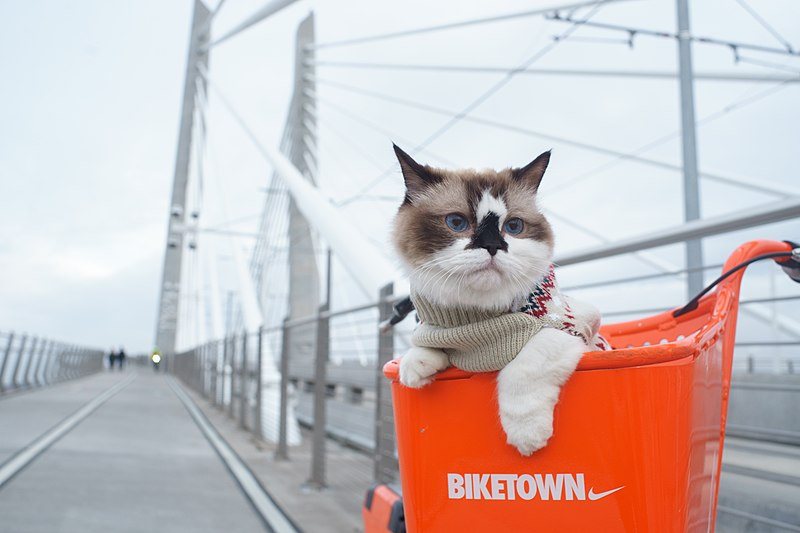
<figcaption aria-hidden="true">Albert in a bike
(catmapper:Wikimedia)</figcaption>
</figure>

## 

<figure>
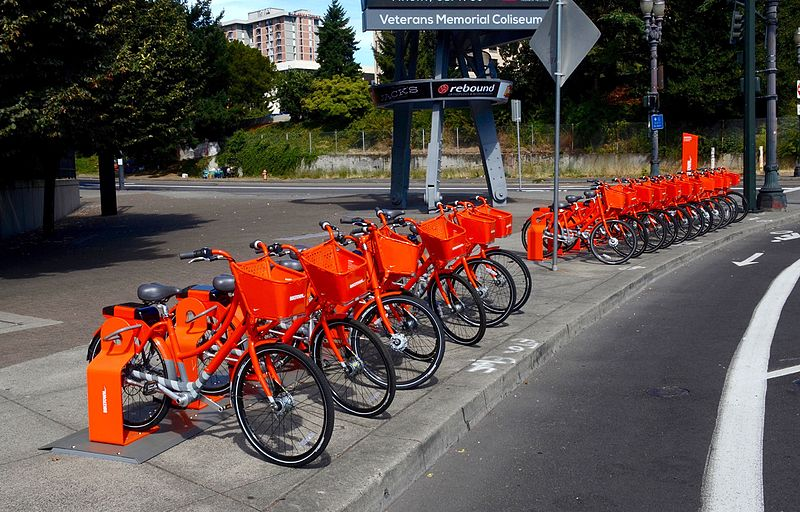
<figcaption aria-hidden="true">biketown bikes (Steve Morgan:
Wikimedia)</figcaption>
</figure>

## 

<figure>
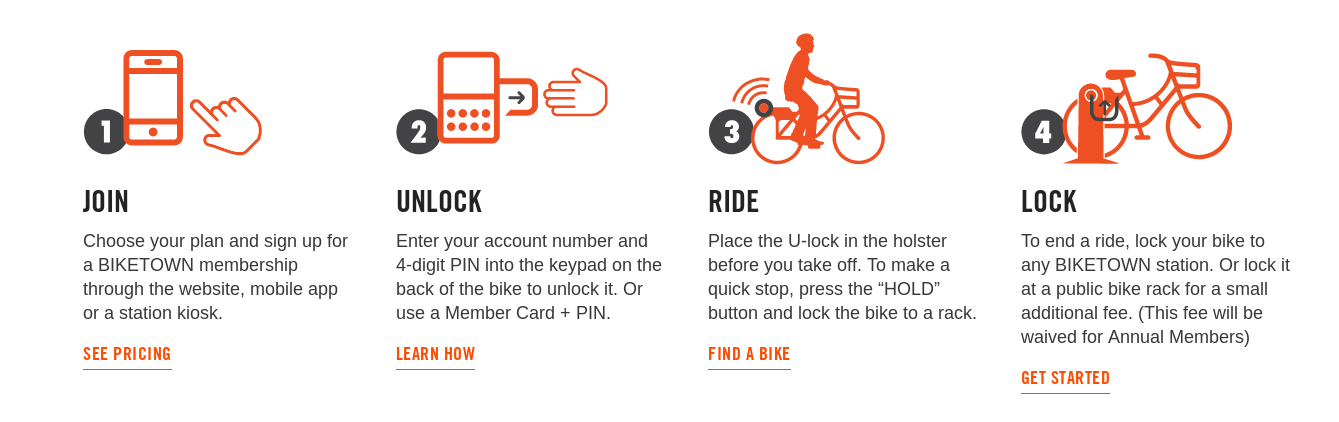
<figcaption aria-hidden="true">how biketown works:
screenshot</figcaption>
</figure>

##

In [ ]:
import pyproj
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import contextily

## August, 2018

Here is data from [August, 2018](data/biketown/2018_08.csv.gz).

In [ ]:
df = pd.read_csv("data/biketown/2018_08.csv.gz")
df = df.loc[~df['StartLatitude'].isna(),:]
df.head(n=5)

## Transform points

First, we’d like actual spatial points in a sensible (isometric)
coordinate system:

In [ ]:
df['start_points'] = gpd.points_from_xy(df.StartLongitude, df.StartLatitude, crs="EPSG:4326").to_crs("EPSG:5070")
df['end_points'] = gpd.points_from_xy(df.EndLongitude, df.EndLatitude, crs="EPSG:4326").to_crs("EPSG:5070")
gdf = gpd.GeoDataFrame(df, geometry=df['start_points'], crs=5070)
gdf[:1000].explore()

## Goals

1.  Where do most trips start?
2.  Where do they end up?
3.  Is there a net flux of bikes anywhere?

We’ll make some maps with *spatial smoothing* to answer this, and
evaluate if that was a good tool for the job.

# Interlude: when there’s lots of data

## Too much data?

In this class we’ve mostly not worried about computation. Modern
computers deal with vectors of length $10^7$–$10^8$ pretty much
instantly.

But, what if you’ve got more? **Options:**

1.  Use less data.
2.  Look at summaries of the data.

Considerations:

-   Do you really need $n=10^{12}$ for whatever you’re looking for?
    Probably not!
-   If you sub-sample, make sure the sub-sampling is appropriate (i.e.,
    if the sub-sample has structure, it’s structure you want to look
    at).
-   You probably want to pilot your summaries on a sub-sample anyhow.

## Too much data, take two

It’s real easy to run into “too much data” in *spatial* contexts,
basically because $N^2 > N$.

Why?

-   *Images/rasters:* my display is 2256 x 1504, which is 3.3M pixels.
    It’s easy to have a lot of images.

-   *Pairwise comparisons:* Many spatial operations require operating
    “nearby” objects. Naively, that requires working with all $O(N^2)$
    pairwise distances.

## Example: kernel density estimation

Suppose we have a bunch of points

$$ (x_1, y_1), \ldots, (x_n, y_n) $$

with density $f(x,y)$, i.e.,

$$
f(x,y) \approx \frac{\#(\text{of points within $r$ of $(x,y)$})}{\pi r^2}
$$

## 

Using (for instance)

$$
\rho_\sigma(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} 
$$

we can estimate $f(x,y)$ by

$$
\hat f(x,y) = \sum_{i=1}^n \rho_\sigma(x_i-x, y_i-y) .
$$

**(interlude: why?)**

## Try it out (in one dimension)

1.  Simulate 200 spatial locations with a density having two “bumps”.
    Plot these points.
    (`rng.normal(size=n, loc=-3), rng.normal(size=n, loc=+3)`)

2.  Make 20 “reference” locations.

3.  Compute the kernel density estimate for each reference location,
    with $\sigma$ chosen appropriately, and plot it.
    (`scipy.stats.norm( )`)

## Uh-oh, it’s quadratic

Note that this required $O(NM)$ operations, where $N$ is the number of
data points, and $M$ is the number of reference locations.

This is not as bad as $O(N^2)$!

But, suppose we wanted “*density estimate for each of our $N$ points*”.
The naive method would use data points = reference points: $O(N^2)$.

*Better:* get estimated density at a grid of references, and use linear
interpolation.

## Guidelines for keeping your computer happy

-   Start with small $N$, look out for things that take a long time.
-   If you actually need “all pairwise” values, keep $N$ small (below
    1,000 or so?).
-   If an operation seems to need pairwise values under the hood, use
    “algorithms”: for instance, [$k-d$
    trees](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html)
    (spatial libraries will do this sort of thing for you).

# Back to the data

## Smoothed map of starting locations

First, we’ll bin things into a 2D grid:

In [ ]:
sigma = 500 # meters
delta = 100 # meters
xy = np.array([x.coords[0] for x in gdf['start_points']])
extent = [np.min(xy[:,1]), np.max(xy[:,1]), np.min(xy[:,0]), np.max(xy[:,0])]
xx = np.linspace(extent[2], extent[3], int(abs(extent[3]-extent[2])/delta))
yy = np.linspace(extent[0], extent[1], int(abs(extent[1]-extent[0])/delta))
heatmap, xedges, yedges = np.histogram2d(xy[:,0], xy[:,1], bins=[xx, yy])
plt.imshow(heatmap)

## 

Then, we smooth it: *(question: how’s this relate to how we did KDE
above?)*

In [ ]:
heatmap = scipy.ndimage.gaussian_filter(heatmap, sigma=sigma/delta, mode='nearest')
plt.imshow(heatmap)

## Better plotting

There’s various ways to do this. One is to use
[contextily](https://contextily.readthedocs.io/en/latest/) as
demonstrated [here](https://py.geocompx.org/08-mapping#basemaps). First,
we need to convert to “EPSG:3857 (Web Mercator)”:

In [ ]:
xpts = gpd.points_from_xy(xx, np.full((len(xx),), np.mean(yy)), crs="EPSG:5070").to_crs("EPSG:3857")
ypts = gpd.points_from_xy(np.full((len(yy),), np.mean(xx)), yy, crs="EPSG:5070").to_crs("EPSG:3857")
gpd.GeoDataFrame(geometry=gpd.points_from_xy(
    np.concat([xx, np.full((len(yy),), np.mean(xx))]), 
    np.concat([np.full((len(xx),), np.mean(yy)), yy])),
    crs="EPSG:5070").to_crs("EPSG:3857").explore()

## 

Now, we can superimpose on the OSM map:

In [ ]:
XX, YY = np.meshgrid(
    [x.coords[0][0] for x in xpts[1:]],
    [y.coords[0][1] for y in ypts[1:]],
)
fig, ax = plt.subplots()
ax.contourf(XX, YY, heatmap.T, alpha=0.3)
contextily.add_basemap(ax);

## 

Let’s zoom in:

In [ ]:
fig, ax = plt.subplots()
ax.contourf(XX, YY, heatmap.T, alpha=0.3)
ax.set_xlim(-1.366e7, -1.3652e7)
ax.set_ylim(5.7e6, 5.707e6)
contextily.add_basemap(ax);

# Bandwidth is important

## Question:

Above I set:

    sigma = 500 # meters
    delta = 100 # meters

What are these numbers, in words, and are these good choices?

## Exercise:

Explore different choices of these two parameters. To do this:

1.  Write a function that takes in `sigma` and `delta` and makes a plot.
2.  Play around with it.

# Choosing a bandwidth

## How to pick a bandwidth?

There are various automatic methods.

But… crossvalidation!

For each bandwidth:

1.  Fit using most of the data,
2.  and predict the remaining data.
3.  Do this a bunch and return an estimate of goodness-of-fit.

… but wait, what’s this mean, here?

## Revised:

For each bandwidth:

1.  Fit the smooth using most of the data,
2.  predict the density at the locations of the remaining data,
3.  and return the mean log density at “true” points.

*Why log?:*

If $f$ and $g$ are probability distributions, and $x_1, \ldots, x_n$ are
drawn from $f$, then
$$  L(g) = \sum_{i=1}^n \log g(x_i) \lessapprox L(f) , $$ i.e., is
maximized for $g=f$. (see: [cross
entropy](https://en.wikipedia.org/wiki/Cross_entropy))